# UHVDB-sylph coverage correlations

Analyses of simulated read profiling with **UHVDB-sylph** only:

1. Pearson *r* between simulated input coverage and sylph `True_cov`, binned by global ANI (`qani`) of each input virus to its most similar UHVDB genome
2. Pearson *r* between simulated input coverage and CoverM `trimmed_mean` (and secondary: vs `True_cov`), binned by CoverM BER (`breadth / expected_breadth`)
3. Pearson *r* between sylph `True_cov` and CoverM `trimmed_mean` as a function of increasing minimum BER thresholds

Input↔detection pairs use **reciprocal best hit (RBH)** linking. Data root: `../figure_4/virome_profiling/`

In [321]:
# Imports and paths
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.stats import pearsonr

DATA = Path('../figure_4/virome_profiling')
ANICALC = DATA / 'uhvdb.anicalc.tsv'
READSIM = DATA / 'readsim'
SYLPH_DIR = DATA / 'uhvdb_sylph_profile'

SPLITS = range(1, 18)
DETECT_THRESH = 0.1
PLOT_FLOOR = 0.1  # non-detections plotted here on log axes (true value = 0)
QANI_LABELS = ['<0.6', '0.6–0.8', '0.8–0.95', '≥0.95']
TANI_LABELS = QANI_LABELS  # same edges for match_tani bins
BER_LABELS = ['<0.4', '0.4–0.6', '0.6–0.8', '≥0.8']
MIN_BER_SWEEP = [round(x, 2) for x in np.arange(0.0, 0.95, 0.05)]

sns.set(style='whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

def body_site_for_split(i: int) -> str:
    if i <= 10:
        return 'gut'
    if i < 15:
        return 'oral'
    if i < 17:
        return 'skin'
    return 'urogenital'

def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, len(x)
    r, _ = pearsonr(x, y)
    return float(r), len(x)

def assign_qani_bin(qani: float) -> str:
    if qani < 0.6:
        return '<0.6'
    if qani < 0.8:
        return '0.6–0.8'
    if qani < 0.95:
        return '0.8–0.95'
    return '≥0.95'

def assign_tani_bin(tani: float) -> str:
    return assign_qani_bin(tani)

def assign_ber_bin(ber: float) -> str:
    if ber < 0.4:
        return '<0.4'
    if ber < 0.6:
        return '0.4–0.6'
    if ber < 0.8:
        return '0.6–0.8'
    return '≥0.8'


def prepare_log_scatter(df, y_col, detect_col=None):
    """Include non-detections as 0; map <=0 to PLOT_FLOOR for log-scale plotting."""
    out = df.copy()
    y = out[y_col].astype(float).fillna(0.0)
    if detect_col is None:
        out['detected'] = y > DETECT_THRESH
    else:
        out['detected'] = out[detect_col].fillna(False).astype(bool) | (y > DETECT_THRESH)
    out['y_plot'] = np.where(y > 0, y, PLOT_FLOOR)
    out['y_raw'] = y
    return out

def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lims, lims, '--', color='red', linewidth=1)

print('DATA =', DATA.resolve())
print('ANICALC exists:', ANICALC.exists())

DATA = /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_4/virome_profiling
ANICALC exists: True


## Shared data prep

Join simulated input coverage, BLAST ANI, sylph `True_cov` (`Adjusted_ANI >= 95`), and CoverM `trimmed_mean` / BER for splits 1–17.

**Reciprocal best hit (RBH) linking:**
- Among sylph-detected UHVDB contigs, each input’s best hit is the contig with highest `match_qani` (`pid * qcov / 10000`)
- Each detected contig’s best input is the one with highest `match_tani` (`pid * tcov / 10000`)
- Keep a pair only when both directions agree (each reference used at most once)

Also retained:
- `qani` = ANI of input → most similar UHVDB genome overall (Analysis 1 bins)
- `BER = breadth_ratio = breadth / (1 - e^(-0.833 * mean))`
- Correlations exclude non-detections (`True_cov` / `trimmed_mean` ≤ 0.1); no `0.1` fill in correlation stats

In [322]:
# Build input_vs_detected and sylph_vs_coverm tables
# Linking: reciprocal best hit (RBH) between inputs and sylph-detected UHVDB contigs
anicalc = pl.read_csv(ANICALC, separator='\t')

input_rows = []
sylph_coverm_rows = []

for i in SPLITS:
    site = body_site_for_split(i)

    input_genomes = (
        pl.read_csv(READSIM / f'split_{i}_reads_cov.txt', separator='\t')
        .rename({'tname': 'qname'})
        .select(['qname', 'genome_length', 'read_count', 'coverage'])
    )
    input_ids = set(input_genomes['qname'].to_list())

    # Global top ANI to any UHVDB genome (Analysis 1 bins)
    qani_global = (
        anicalc
        .filter(pl.col('qname').is_in(input_ids))
        .with_columns(((pl.col('pid') * pl.col('qcov')) / 10000).alias('qani'))
        .sort('qani', descending=True)
        .unique('qname', maintain_order=True)
        .select(['qname', 'qani'])
    )

    sylph = (
        pl.read_csv(
            SYLPH_DIR / f'split_{i}' / f'split_{i}_uhvdb_globdb.profile.tsv',
            separator='\t',
            ignore_errors=True,
        )
        .with_columns(pl.col('Contig_name').str.split(' ').list.first().alias('contig_id'))
        .filter(pl.col('Adjusted_ANI') >= 95)
        .select(['contig_id', 'True_cov', 'Adjusted_ANI'])
    )

    coverm = (
        pl.read_csv(
            SYLPH_DIR / f'split_{i}' / f'split_{i}_uhvdb_globdb.coverm.tsv',
            separator='\t',
            new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length'],
        )
        .with_columns((pl.col('covered_bases') / pl.col('length')).alias('breadth'))
        .with_columns((1 - math.e ** (-0.833 * pl.col('mean'))).alias('expected_breadth'))
        .with_columns((pl.col('breadth') / pl.col('expected_breadth')).alias('breadth_ratio'))
        .select(['contig_id', 'trimmed_mean', 'mean', 'breadth', 'breadth_ratio'])
    )

    detected_ids = set(sylph['contig_id'].to_list())

    # All ANI links between inputs and sylph-detected contigs
    links = (
        anicalc
        .filter(pl.col('qname').is_in(input_ids) & pl.col('tname').is_in(detected_ids))
        .with_columns([
            ((pl.col('pid') * pl.col('qcov')) / 10000).alias('match_qani'),
            ((pl.col('pid') * pl.col('tcov')) / 10000).alias('match_tani'),
        ])
        .select(['qname', pl.col('tname').alias('contig_id'), 'match_qani', 'match_tani', 'tcov'])
    )

    # Input → best detected contig by match_qani
    best_for_input = (
        links
        .sort('match_qani', descending=True)
        .unique('qname', maintain_order=True)
    )

    # Contig → best input by match_tani
    best_for_contig = (
        links
        .sort('match_tani', descending=True)
        .unique('contig_id', maintain_order=True)
        .select(['qname', 'contig_id'])
    )

    # Best link to any detected contig (for RBH-rate vs ANI plots; not necessarily RBH)
    best_link_tani = (
        links
        .sort('match_tani', descending=True)
        .unique('qname', maintain_order=True)
        .select([
            'qname',
            pl.col('contig_id').alias('best_link_contig_id'),
            pl.col('match_tani').alias('best_link_tani'),
            pl.col('tcov').alias('best_link_tcov'),  # 0–100% target coverage of best tANI link
        ])
        .join(
            coverm.select([
                pl.col('contig_id').alias('best_link_contig_id'),
                pl.col('breadth_ratio').alias('best_link_breadth_ratio'),
                pl.col('trimmed_mean').alias('best_link_trimmed_mean'),
            ]),
            on='best_link_contig_id',
            how='left',
        )
    )
    best_link_qani = (
        links
        .sort('match_qani', descending=True)
        .unique('qname', maintain_order=True)
        .select(['qname', pl.col('match_qani').alias('best_link_qani')])
    )

    # RBH: both directions agree on the same pair
    rbh = (
        best_for_input
        .join(best_for_contig, on=['qname', 'contig_id'], how='inner')
        .with_columns(pl.col('tcov').alias('match_tcov'))  # BLAST tcov of RBH pair (0–100%)
        .drop('tcov')
        .join(sylph, on='contig_id', how='left')
        .join(coverm, on='contig_id', how='left')
    )

    input_w_detected = (
        input_genomes
        .join(qani_global, on='qname', how='left')
        .with_columns(pl.col('qani').fill_null(0.0))
        .join(best_link_tani, on='qname', how='left')
        .join(best_link_qani, on='qname', how='left')
        .join(rbh, on='qname', how='left')
        .with_columns([
            pl.lit(i).alias('split'),
            pl.lit(site).alias('body_site'),
            pl.col('contig_id').is_not_null().alias('has_rbh'),
        ])
    )
    input_rows.append(input_w_detected)

    # Direct sylph ↔ CoverM join on contig_id (for analysis 3)
    sylph_vs_cm = (
        sylph
        .join(coverm, on='contig_id', how='inner')
        .with_columns([
            pl.lit(i).alias('split'),
            pl.lit(site).alias('body_site'),
        ])
    )
    sylph_coverm_rows.append(sylph_vs_cm)

input_vs_detected = pl.concat(input_rows, how='diagonal_relaxed')
sylph_vs_coverm = pl.concat(sylph_coverm_rows, how='diagonal_relaxed')

input_vs_detected = input_vs_detected.with_columns([
    pl.col('qani').map_elements(assign_qani_bin, return_dtype=pl.Utf8).alias('qani_bin'),
    pl.when(pl.col('match_tani').is_not_null())
      .then(pl.col('match_tani').map_elements(assign_tani_bin, return_dtype=pl.Utf8))
      .otherwise(None)
      .alias('tani_bin'),
    pl.when(pl.col('best_link_tani').is_not_null())
      .then(pl.col('best_link_tani').map_elements(assign_tani_bin, return_dtype=pl.Utf8))
      .otherwise(None)
      .alias('best_link_tani_bin'),
    pl.when(pl.col('breadth_ratio').is_not_null())
      .then(pl.col('breadth_ratio').map_elements(assign_ber_bin, return_dtype=pl.Utf8))
      .otherwise(None)
      .alias('ber_bin'),
])
sylph_vs_coverm = sylph_vs_coverm.with_columns(
    pl.col('breadth_ratio').map_elements(assign_ber_bin, return_dtype=pl.Utf8).alias('ber_bin')
)

n_rbh = input_vs_detected.filter(pl.col('contig_id').is_not_null()).height
n_dup_ref = (
    input_vs_detected
    .filter(pl.col('contig_id').is_not_null())
    .group_by(['split', 'contig_id'])
    .len()
    .filter(pl.col('len') > 1)
    .height
)

print('input_vs_detected:', input_vs_detected.shape)
print('sylph_vs_coverm:', sylph_vs_coverm.shape)
print('RBH pairs:', n_rbh)
print('Duplicate reference assignments (should be 0):', n_dup_ref)
print('Detected True_cov > 0.1:', input_vs_detected.filter(pl.col('True_cov') > DETECT_THRESH).height)
print('Detected trimmed_mean > 0.1:', input_vs_detected.filter(pl.col('trimmed_mean') > DETECT_THRESH).height)
input_vs_detected.head()

input_vs_detected: (1700, 28)
sylph_vs_coverm: (1535, 10)
RBH pairs: 1391
Duplicate reference assignments (should be 0): 0
Detected True_cov > 0.1: 1390
Detected trimmed_mean > 0.1: 1389


qname,genome_length,read_count,coverage,qani,best_link_contig_id,best_link_tani,best_link_tcov,best_link_breadth_ratio,best_link_trimmed_mean,best_link_qani,contig_id,match_qani,match_tani,match_tcov,True_cov,Adjusted_ANI,trimmed_mean,mean,breadth,breadth_ratio,split,body_site,has_rbh,qani_bin,tani_bin,best_link_tani_bin,ber_bin
str,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,str,bool,str,str,str,str
"""ERR15204861_k251_10829""",56605,3240,17.171628,0.834196,"""UHGV-0391979""",0.89872,91.51,0.851559,11.805993,0.834196,"""UHGV-0391979""",0.834196,0.89872,91.51,17.937,99.16,11.805993,12.011623,0.851521,0.851559,1,"""gut""",true,"""0.8–0.95""","""0.8–0.95""","""0.8–0.95""","""≥0.8"""
"""SRR33526932_k251_140026""",178601,348,0.584543,0.850167,"""UHGV-1375748""",0.85599,88.21,1.098449,0.3587371,0.850167,"""UHGV-1375748""",0.850167,0.85599,88.21,0.42,99.57,0.3587371,0.440252,0.337228,1.098449,1,"""gut""",true,"""0.8–0.95""","""0.8–0.95""","""0.8–0.95""","""≥0.8"""
"""ERR14118117_k251_167070""",13645,376,8.266764,0.997,"""UHGV-1381292""",0.993511,99.65,0.988122,8.167568,0.997,"""UHGV-1381292""",0.997,0.993511,99.65,8.573,99.93,8.167568,8.23111,0.987082,0.988122,1,"""gut""",true,"""≥0.95""","""≥0.95""","""≥0.95""","""≥0.8"""
"""SRR33524362_k251_1086""",5947,218,10.997141,0.892719,"""v89446""",0.883381,94.55,0.825693,6.128471,0.868338,"""v89446""",0.868338,0.883381,94.55,12.188,96.04,6.128471,6.499824,0.822016,0.825693,1,"""gut""",true,"""0.8–0.95""","""0.8–0.95""","""0.8–0.95""","""≥0.8"""
"""SRR24045103_k251_219477""",30007,1518,15.176459,0.858654,"""FTJBH45_vae_152""",0.165218,16.54,0.452898,2.1100516,0.858654,null,null,null,null,null,null,null,null,null,null,1,"""gut""",false,"""0.8–0.95""",null,"""<0.6""",null


## Analysis 1 — Pearson *r* by global ANI bins

Simulated input coverage vs sylph `True_cov`, stratified by `qani` of the input to its top UHVDB hit.


In [323]:
# Analysis 1: summary stats by qANI bin
a1 = input_vs_detected.filter(pl.col('True_cov') > DETECT_THRESH)

a1_stats = []
for label in QANI_LABELS:
    sub = a1.filter(pl.col('qani_bin') == label)
    r, n = safe_pearson(sub['coverage'].to_list(), sub['True_cov'].to_list())
    total_in_bin = input_vs_detected.filter(pl.col('qani_bin') == label).height
    recall = (sub.height / total_in_bin * 100) if total_in_bin else np.nan
    false_hits = sub.filter(pl.col('qani') < 0.6).height
    med_ratio = mae = np.nan
    if n >= 1:
        ratios = (sub['True_cov'] / sub['coverage']).to_numpy()
        med_ratio = float(np.nanmedian(ratios))
        mae = float(np.nanmean(np.abs(sub['True_cov'].to_numpy() - sub['coverage'].to_numpy())))
    a1_stats.append({
        'qani_bin': label,
        'n': n,
        'n_total': total_in_bin,
        'recall_pct': recall,
        'pearson_r': r,
        'median_True_cov_over_input': med_ratio,
        'mae': mae,
        'false_hit_n': false_hits if label == '<0.6' else 0,
    })

a1_stats_df = pd.DataFrame(a1_stats)
display(a1_stats_df)

,qani_bin,n,n_total,recall_pct,pearson_r,median_True_cov_over_input,mae,false_hit_n
0,<0.6,49,162,30.246914,0.984446,1.054396,1.547027,49
1,0.6–0.8,288,338,85.207101,0.981653,1.061197,1.592516,0
2,0.8–0.95,802,933,85.959271,0.962124,1.051005,1.959966,0
3,≥0.95,251,267,94.007491,0.985857,1.062692,3.987383,0


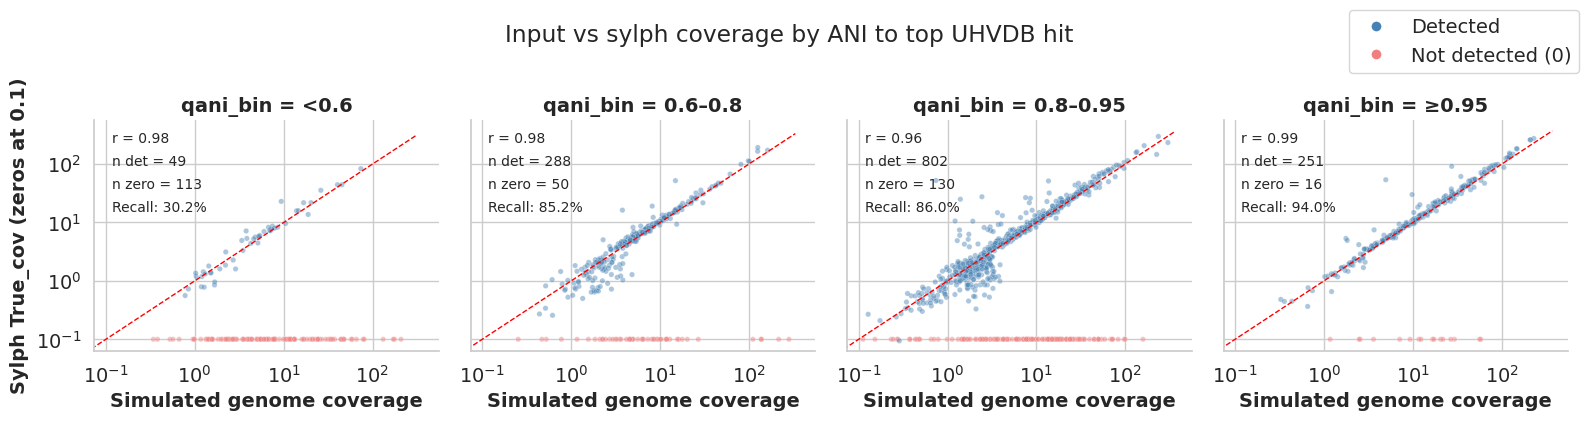

In [324]:
# Analysis 1: log-log scatter faceted by qANI bin (include non-detections as 0)
# Non-detections are shown at PLOT_FLOOR on the log y-axis
plot_df = prepare_log_scatter(
    input_vs_detected.to_pandas(),
    y_col='True_cov',
    detect_col='has_rbh',
)
plot_df['qani_bin'] = pd.Categorical(plot_df['qani_bin'], categories=QANI_LABELS, ordered=True)

g = sns.FacetGrid(plot_df, col='qani_bin', col_order=QANI_LABELS, margin_titles=True, height=4, aspect=1)
g.map_dataframe(
    sns.scatterplot, x='coverage', y='y_plot', hue='detected',
    palette={True: 'steelblue', False: 'lightcoral'},
    s=15, alpha=0.45, legend=False,
)
g.map_dataframe(one_to_one_line)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')

for ax in g.axes.flat:
    title = ax.get_title()
    label = title.split(' = ')[-1] if ' = ' in title else title
    row = a1_stats_df.loc[a1_stats_df['qani_bin'] == label]
    if len(row):
        r = row['pearson_r'].iloc[0]
        n = int(row['n'].iloc[0])
        rec = row['recall_pct'].iloc[0]
        n_zero = int((~plot_df.loc[plot_df['qani_bin'] == label, 'detected']).sum())
        ax.text(0.05, 0.95, f'r = {r:.2f}' if np.isfinite(r) else 'r = NA',
                transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.85, f'n det = {n}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.75, f'n zero = {n_zero}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.65, f'Recall: {rec:.1f}%', transform=ax.transAxes, va='top', fontsize=10)

g.set_axis_labels('Simulated genome coverage', f'Sylph True_cov (zeros at {PLOT_FLOOR})')
g.fig.suptitle('Input vs sylph coverage by ANI to top UHVDB hit', y=1.02)
# single legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Detected'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=8, label='Not detected (0)'),
]
g.fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.0, 1.08))
plt.tight_layout()
plt.show()

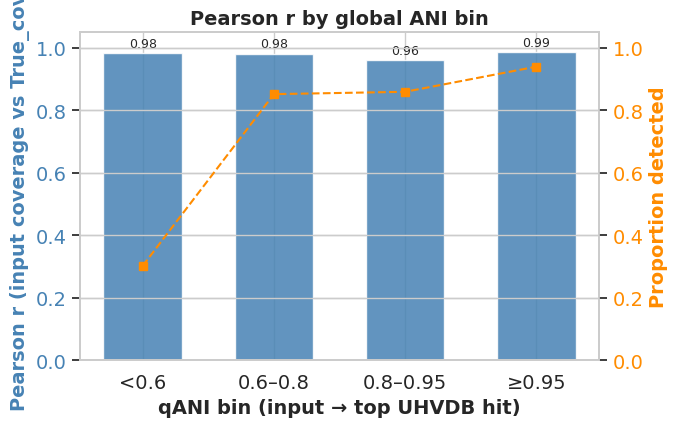

In [325]:
# Analysis 1: summary bar of Pearson r (and proportion detected) by qANI bin
fig, ax1 = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(a1_stats_df))
prop_detected = a1_stats_df['n'] / a1_stats_df['n_total']
ax1.bar(x, a1_stats_df['pearson_r'], color='steelblue', alpha=0.85, width=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(a1_stats_df['qani_bin'])
ax1.set_ylabel('Pearson r (input coverage vs True_cov)', color='steelblue')
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor='steelblue')
for i, r in enumerate(a1_stats_df['pearson_r']):
    if np.isfinite(r):
        ax1.text(i, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, prop_detected, marker='s', color='darkorange', linestyle='--')
ax2.set_ylabel('Proportion detected', color='darkorange')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_xlabel('qANI bin (input → top UHVDB hit)')
ax1.set_title('Pearson r by global ANI bin')
plt.tight_layout()
plt.show()

## Analysis 1b — Input vs sylph coverage by tANI bins

Same as Analysis 1, but stratified by RBH `match_tani` (UHVDB hit → input).


,tani_bin,n,n_total,recall_pct,pearson_r
0,<0.6,81,121,66.942149,0.958273
1,0.6–0.8,367,390,94.102564,0.962380
2,0.8–0.95,715,766,93.342037,0.975667
3,≥0.95,227,240,94.583333,0.974718


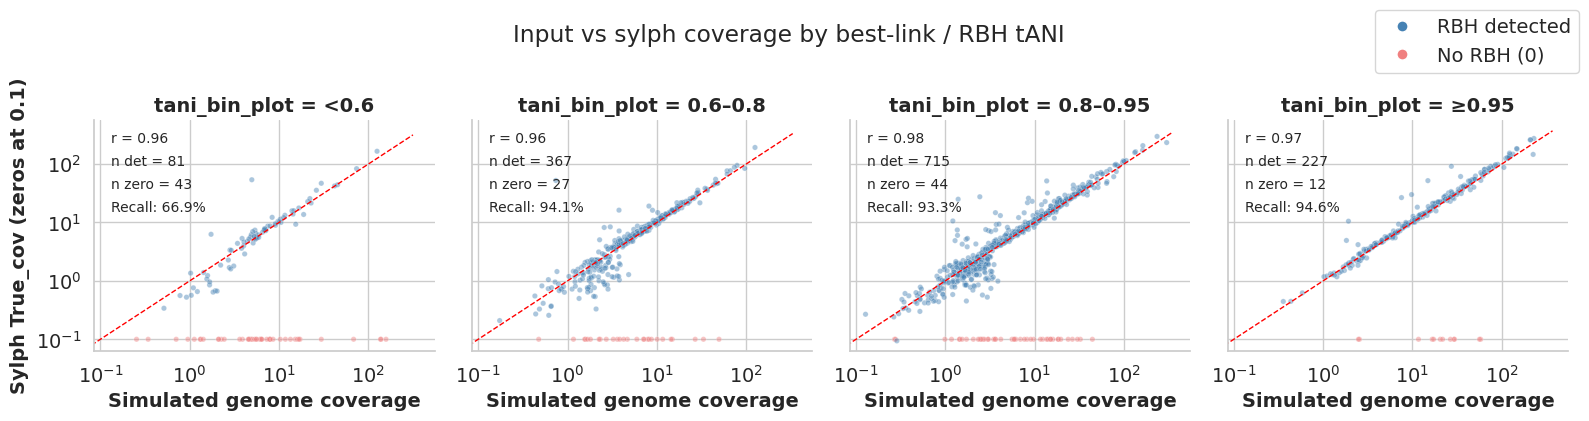

In [326]:
# Analysis 1b: input vs sylph coverage by tANI bin
# Include non-RBH genomes that have a best link to a sylph hit (shown as True_cov = 0)
a1_tani_det = input_vs_detected.filter(
    (pl.col('True_cov') > DETECT_THRESH) & pl.col('tani_bin').is_not_null()
)

a1_tani_stats = []
for label in TANI_LABELS:
    sub = a1_tani_det.filter(pl.col('tani_bin') == label)
    r, n = safe_pearson(sub['coverage'].to_list(), sub['True_cov'].to_list())
    # denom: inputs whose best link tANI falls in this bin (RBH or not)
    total_in_bin = input_vs_detected.filter(pl.col('best_link_tani_bin') == label).height
    recall = (sub.height / total_in_bin * 100) if total_in_bin else np.nan
    a1_tani_stats.append({
        'tani_bin': label,
        'n': n,
        'n_total': total_in_bin,
        'recall_pct': recall,
        'pearson_r': r,
    })
a1_tani_stats_df = pd.DataFrame(a1_tani_stats)
display(a1_tani_stats_df)

plot_src = (
    input_vs_detected
    .filter(pl.col('best_link_tani_bin').is_not_null())
    .with_columns(pl.col('best_link_tani_bin').alias('tani_bin_plot'))
    .to_pandas()
)
plot_df = prepare_log_scatter(plot_src, y_col='True_cov', detect_col='has_rbh')
plot_df['tani_bin_plot'] = pd.Categorical(plot_df['tani_bin_plot'], categories=TANI_LABELS, ordered=True)

g = sns.FacetGrid(plot_df, col='tani_bin_plot', col_order=TANI_LABELS, margin_titles=True, height=4, aspect=1)
g.map_dataframe(
    sns.scatterplot, x='coverage', y='y_plot', hue='detected',
    palette={True: 'steelblue', False: 'lightcoral'},
    s=15, alpha=0.45, legend=False,
)
g.map_dataframe(one_to_one_line)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')
    label = ax.get_title().split(' = ')[-1] if ' = ' in ax.get_title() else ax.get_title()
    row = a1_tani_stats_df.loc[a1_tani_stats_df['tani_bin'] == label]
    if len(row):
        r = row['pearson_r'].iloc[0]
        n = int(row['n'].iloc[0])
        n_zero = int((~plot_df.loc[plot_df['tani_bin_plot'] == label, 'detected']).sum())
        rec = row['recall_pct'].iloc[0]
        ax.text(0.05, 0.95, f'r = {r:.2f}' if np.isfinite(r) else 'r = NA',
                transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.85, f'n det = {n}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.75, f'n zero = {n_zero}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.65, f'Recall: {rec:.1f}%', transform=ax.transAxes, va='top', fontsize=10)

g.set_axis_labels('Simulated genome coverage', f'Sylph True_cov (zeros at {PLOT_FLOOR})')
g.fig.suptitle('Input vs sylph coverage by best-link / RBH tANI', y=1.02)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='RBH detected'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=8, label='No RBH (0)'),
]
g.fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.0, 1.08))
plt.tight_layout()
plt.show()

## Analysis 1c — Proportion of genomes with an RBH by ANI / tcov

- **By qANI:** fraction of all input genomes in each global `qani` bin that have an RBH pair
- **By tANI:** fraction of inputs with ≥1 ANI link to a sylph-detected contig, binned by their best `match_tani` to any detected contig, that are RBHs
- **By tcov:** same denominator as tANI, binned by BLAST target coverage (`tcov`) of that best-tANI link — a closer proxy for how much of the UHVDB genome is alignable (related to CoverM BER)

,ani_bin,ani_type,n_total,n_rbh,prop_rbh
0,<0.6,qANI (global),162,49,0.302469
1,0.6–0.8,qANI (global),338,288,0.852071
2,0.8–0.95,qANI (global),933,803,0.860665
3,≥0.95,qANI (global),267,251,0.940075
4,<0.6,best link tANI,121,78,0.644628
5,0.6–0.8,best link tANI,390,363,0.930769
6,0.8–0.95,best link tANI,766,722,0.942559
7,≥0.95,best link tANI,240,228,0.950000


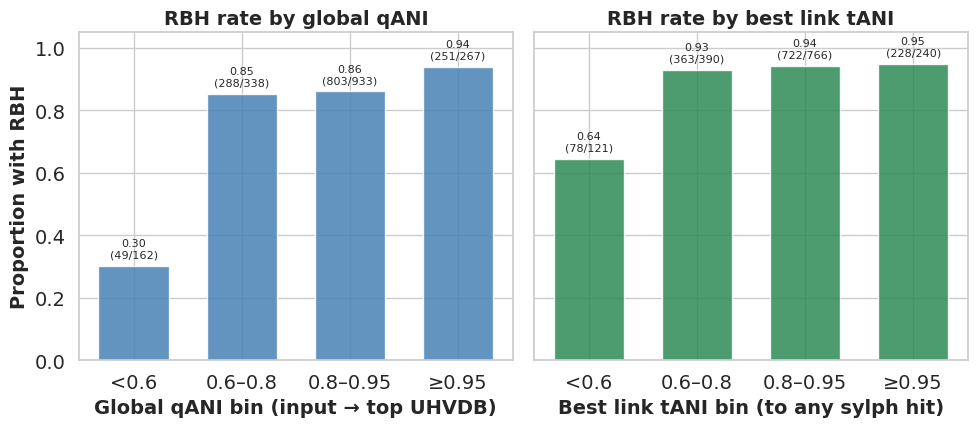

In [327]:
# Analysis 1c: proportion of genomes with RBH by qANI and tANI
# qANI: all inputs, global qani bins
rbh_by_qani = []
for label in QANI_LABELS:
    sub = input_vs_detected.filter(pl.col('qani_bin') == label)
    n_total = sub.height
    n_rbh = sub.filter(pl.col('has_rbh')).height
    rbh_by_qani.append({
        'ani_bin': label,
        'ani_type': 'qANI (global)',
        'n_total': n_total,
        'n_rbh': n_rbh,
        'prop_rbh': n_rbh / n_total if n_total else np.nan,
    })

# tANI: inputs with a link to ≥1 detected contig, binned by best_link_tani
rbh_by_tani = []
for label in TANI_LABELS:
    sub = input_vs_detected.filter(pl.col('best_link_tani_bin') == label)
    n_total = sub.height
    n_rbh = sub.filter(pl.col('has_rbh')).height
    rbh_by_tani.append({
        'ani_bin': label,
        'ani_type': 'best link tANI',
        'n_total': n_total,
        'n_rbh': n_rbh,
        'prop_rbh': n_rbh / n_total if n_total else np.nan,
    })

rbh_prop_df = pd.DataFrame(rbh_by_qani + rbh_by_tani)
display(rbh_prop_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

qdf = rbh_prop_df[rbh_prop_df['ani_type'] == 'qANI (global)']
axes[0].bar(np.arange(len(qdf)), qdf['prop_rbh'], color='steelblue', alpha=0.85, width=0.65)
axes[0].set_xticks(np.arange(len(qdf)))
axes[0].set_xticklabels(qdf['ani_bin'])
axes[0].set_xlabel('Global qANI bin (input → top UHVDB)')
axes[0].set_ylabel('Proportion with RBH')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('RBH rate by global qANI')
for i, (p, n, tot) in enumerate(zip(qdf['prop_rbh'], qdf['n_rbh'], qdf['n_total'])):
    axes[0].text(i, p + 0.02, f'{p:.2f}\n({n}/{tot})', ha='center', va='bottom', fontsize=8)

tdf = rbh_prop_df[rbh_prop_df['ani_type'] == 'best link tANI']
axes[1].bar(np.arange(len(tdf)), tdf['prop_rbh'], color='seagreen', alpha=0.85, width=0.65)
axes[1].set_xticks(np.arange(len(tdf)))
axes[1].set_xticklabels(tdf['ani_bin'])
axes[1].set_xlabel('Best link tANI bin (to any sylph hit)')
axes[1].set_title('RBH rate by best link tANI')
for i, (p, n, tot) in enumerate(zip(tdf['prop_rbh'], tdf['n_rbh'], tdf['n_total'])):
    axes[1].text(i, p + 0.02, f'{p:.2f}\n({n}/{tot})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

,tcov_bin,n_total,n_rbh,prop_rbh
0,<20,20,0,0.000000
1,20–40,16,10,0.625000
2,40–50,22,15,0.681818
3,50–60,43,37,0.860465
4,60–70,92,83,0.902174
5,70–80,199,190,0.954774
6,80–90,374,353,0.943850
7,≥90,751,703,0.936085


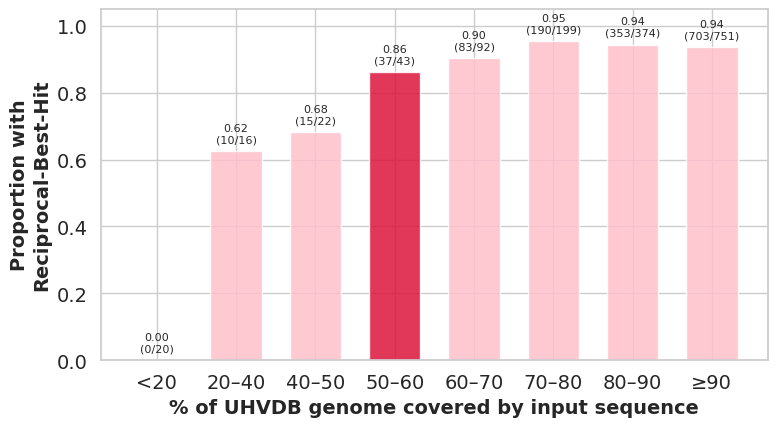

In [328]:
# Analysis 1c (continued): proportion with RBH vs BLAST tcov of best tANI link
# tcov is 0–100%; finer bins as a BER-related alignment-coverage proxy
TCOV_EDGES = [0, 20, 40, 50, 60, 70, 80, 90, 101]
TCOV_LABELS = ['<20', '20–40', '40–50', '50–60', '60–70', '70–80', '80–90', '≥90']

def assign_tcov_bin(tcov: float) -> str:
    for hi, lab in zip(TCOV_EDGES[1:], TCOV_LABELS):
        if tcov < hi:
            return lab
    return TCOV_LABELS[-1]

tcov_df = (
    input_vs_detected
    .filter(pl.col('best_link_tcov').is_not_null())
    .with_columns(
        pl.col('best_link_tcov').map_elements(assign_tcov_bin, return_dtype=pl.Utf8).alias('best_link_tcov_bin')
    )
)

rbh_by_tcov = []
for label in TCOV_LABELS:
    sub = tcov_df.filter(pl.col('best_link_tcov_bin') == label)
    n_total = sub.height
    n_rbh = sub.filter(pl.col('has_rbh')).height
    rbh_by_tcov.append({
        'tcov_bin': label,
        'n_total': n_total,
        'n_rbh': n_rbh,
        'prop_rbh': n_rbh / n_total if n_total else np.nan,
    })

rbh_tcov_df = pd.DataFrame(rbh_by_tcov)
display(rbh_tcov_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(rbh_tcov_df))
bar_colors = ['crimson' if lab == '50–60' else 'pink' for lab in rbh_tcov_df['tcov_bin']]
ax.bar(x, rbh_tcov_df['prop_rbh'], color=bar_colors, alpha=0.85, width=0.65)
ax.set_xticks(x)
ax.set_xticklabels(rbh_tcov_df['tcov_bin'])
ax.set_xlabel('% of UHVDB genome covered by input sequence')
ax.set_ylabel('Proportion with\nReciprocal-Best-Hit')
ax.set_ylim(0, 1.05)
# ax.set_title('RBH rate by BLAST tcov of best tANI link')
for i, (p, n, tot) in enumerate(zip(rbh_tcov_df['prop_rbh'], rbh_tcov_df['n_rbh'], rbh_tcov_df['n_total'])):
    y = p if np.isfinite(p) else 0.0
    ax.text(i, y + 0.02, f'{p:.2f}\n({n}/{tot})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Analysis 2 — Pearson *r* by CoverM BER bins

Primary: simulated coverage vs CoverM `trimmed_mean`. Secondary: vs sylph `True_cov`. Restricted to inputs with non-null CoverM BER.


In [329]:
# Analysis 2: summary stats by BER bin
a2 = input_vs_detected.filter(pl.col('breadth_ratio').is_not_null())
n_total_inputs = input_vs_detected.height

a2_stats = []
for label in BER_LABELS:
    sub = a2.filter(pl.col('ber_bin') == label)
    cm_sub = sub.filter(pl.col('trimmed_mean') > DETECT_THRESH)
    r_cm, n_cm = safe_pearson(cm_sub['coverage'].to_list(), cm_sub['trimmed_mean'].to_list())
    sy_sub = sub.filter(pl.col('True_cov') > DETECT_THRESH)
    r_sy, n_sy = safe_pearson(sy_sub['coverage'].to_list(), sy_sub['True_cov'].to_list())

    med_cm = mae_cm = med_sy = mae_sy = np.nan
    if n_cm >= 1:
        med_cm = float(np.nanmedian((cm_sub['trimmed_mean'] / cm_sub['coverage']).to_numpy()))
        mae_cm = float(np.nanmean(np.abs(cm_sub['trimmed_mean'].to_numpy() - cm_sub['coverage'].to_numpy())))
    if n_sy >= 1:
        med_sy = float(np.nanmedian((sy_sub['True_cov'] / sy_sub['coverage']).to_numpy()))
        mae_sy = float(np.nanmean(np.abs(sy_sub['True_cov'].to_numpy() - sy_sub['coverage'].to_numpy())))

    a2_stats.append({
        'ber_bin': label,
        'n_coverm': n_cm,
        'pearson_r_coverm': r_cm,
        'median_trimmed_mean_over_input': med_cm,
        'mae_coverm': mae_cm,
        'n_sylph': n_sy,
        'pearson_r_sylph': r_sy,
        'median_True_cov_over_input': med_sy,
        'mae_sylph': mae_sy,
        'n_with_ber': sub.height,
        'n_total_inputs': n_total_inputs,
        # Detected in this BER bin / all input viruses
        'prop_detected': n_cm / n_total_inputs if n_total_inputs else np.nan,
    })

a2_stats_df = pd.DataFrame(a2_stats)
display(a2_stats_df)

,ber_bin,n_coverm,pearson_r_coverm,median_trimmed_mean_over_input,mae_coverm,n_sylph,pearson_r_sylph,median_True_cov_over_input,mae_sylph,n_with_ber,n_total_inputs,prop_detected
0,<0.4,12,0.291587,0.199427,13.805248,12,0.495008,1.146543,6.270831,12,1700,0.007059
1,0.4–0.6,96,0.888225,0.397200,11.003532,96,0.976768,1.092400,3.354674,96,1700,0.056471
2,0.6–0.8,393,0.951702,0.568628,5.073987,393,0.969128,1.058022,1.864971,393,1700,0.231176
3,≥0.8,888,0.966866,0.786363,2.271425,889,0.980003,1.048566,2.223782,890,1700,0.522353


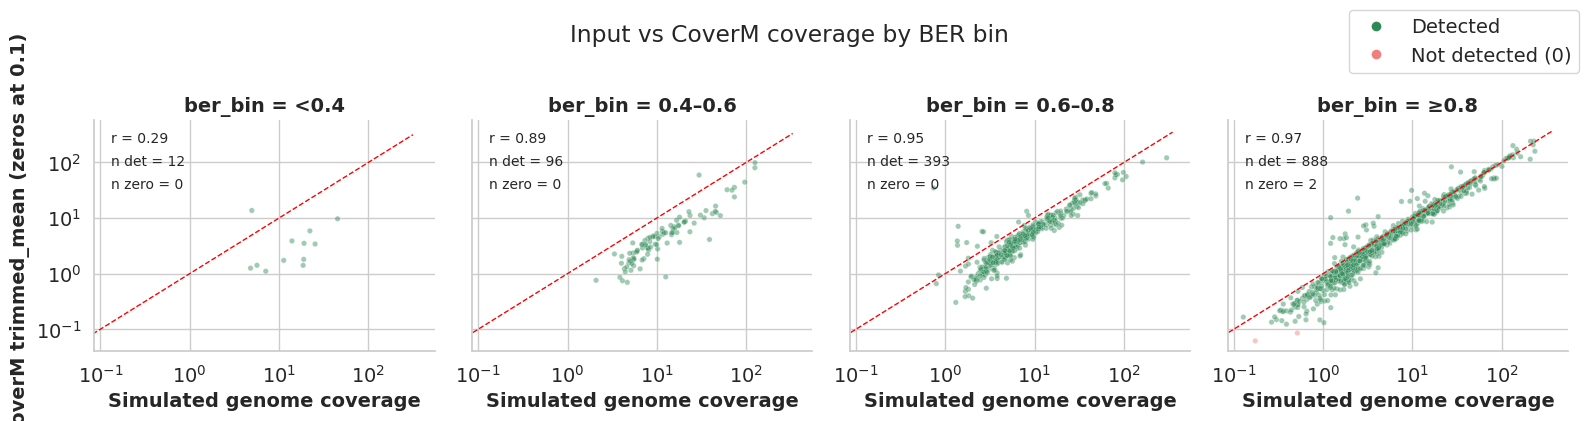

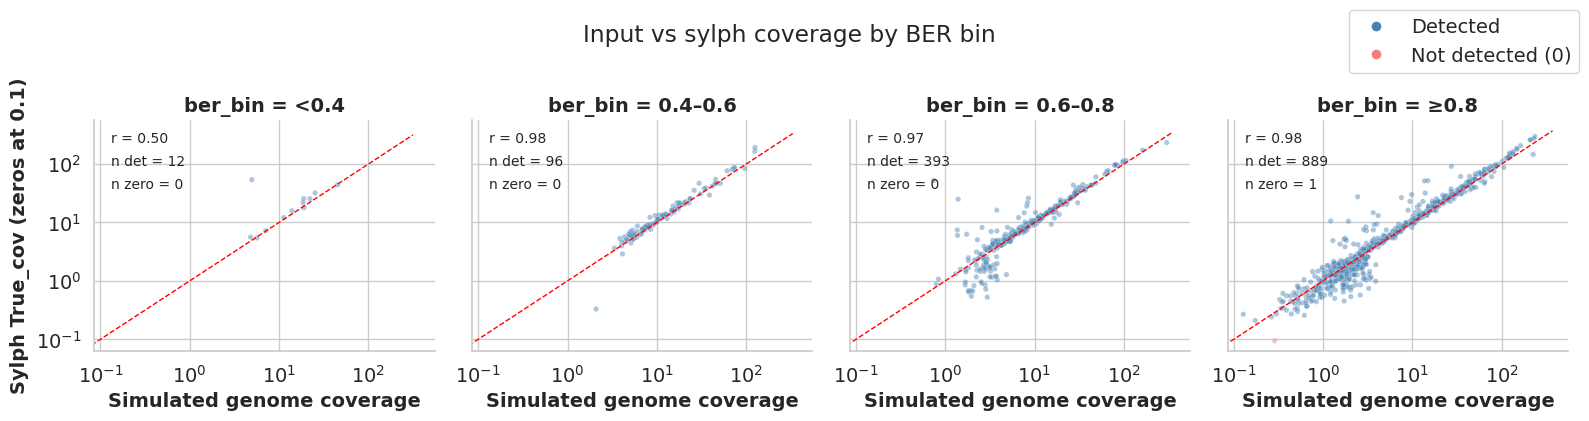

In [330]:
# Analysis 2: faceted scatters — CoverM (primary) and sylph (secondary)
# Include non-detections as 0 (shown at PLOT_FLOOR on log axes)
a2_pd = a2.to_pandas()
a2_pd['ber_bin'] = pd.Categorical(a2_pd['ber_bin'], categories=BER_LABELS, ordered=True)

# Primary: input vs CoverM trimmed_mean
cm_plot = prepare_log_scatter(a2_pd, y_col='trimmed_mean')
g = sns.FacetGrid(cm_plot, col='ber_bin', col_order=BER_LABELS, margin_titles=True, height=4, aspect=1)
g.map_dataframe(
    sns.scatterplot, x='coverage', y='y_plot', hue='detected',
    palette={True: 'seagreen', False: 'lightcoral'},
    s=15, alpha=0.45, legend=False,
)
g.map_dataframe(one_to_one_line)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')
    label = ax.get_title().split(' = ')[-1] if ' = ' in ax.get_title() else ax.get_title()
    row = a2_stats_df.loc[a2_stats_df['ber_bin'] == label]
    if len(row):
        r = row['pearson_r_coverm'].iloc[0]
        n = int(row['n_coverm'].iloc[0])
        n_zero = int((~cm_plot.loc[cm_plot['ber_bin'] == label, 'detected']).sum())
        ax.text(0.05, 0.95, f'r = {r:.2f}' if np.isfinite(r) else 'r = NA',
                transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.85, f'n det = {n}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.75, f'n zero = {n_zero}', transform=ax.transAxes, va='top', fontsize=10)
g.set_axis_labels('Simulated genome coverage', f'CoverM trimmed_mean (zeros at {PLOT_FLOOR})')
g.fig.suptitle('Input vs CoverM coverage by BER bin', y=1.02)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='seagreen', markersize=8, label='Detected'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=8, label='Not detected (0)'),
]
g.fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.0, 1.08))
plt.tight_layout()
plt.show()

# Secondary: input vs sylph True_cov
sy_plot = prepare_log_scatter(a2_pd, y_col='True_cov')
g = sns.FacetGrid(sy_plot, col='ber_bin', col_order=BER_LABELS, margin_titles=True, height=4, aspect=1)
g.map_dataframe(
    sns.scatterplot, x='coverage', y='y_plot', hue='detected',
    palette={True: 'steelblue', False: 'lightcoral'},
    s=15, alpha=0.45, legend=False,
)
g.map_dataframe(one_to_one_line)
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')
    label = ax.get_title().split(' = ')[-1] if ' = ' in ax.get_title() else ax.get_title()
    row = a2_stats_df.loc[a2_stats_df['ber_bin'] == label]
    if len(row):
        r = row['pearson_r_sylph'].iloc[0]
        n = int(row['n_sylph'].iloc[0])
        n_zero = int((~sy_plot.loc[sy_plot['ber_bin'] == label, 'detected']).sum())
        ax.text(0.05, 0.95, f'r = {r:.2f}' if np.isfinite(r) else 'r = NA',
                transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.85, f'n det = {n}', transform=ax.transAxes, va='top', fontsize=10)
        ax.text(0.05, 0.75, f'n zero = {n_zero}', transform=ax.transAxes, va='top', fontsize=10)
g.set_axis_labels('Simulated genome coverage', f'Sylph True_cov (zeros at {PLOT_FLOOR})')
g.fig.suptitle('Input vs sylph coverage by BER bin', y=1.02)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Detected'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=8, label='Not detected (0)'),
]
g.fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.0, 1.08))
plt.tight_layout()
plt.show()

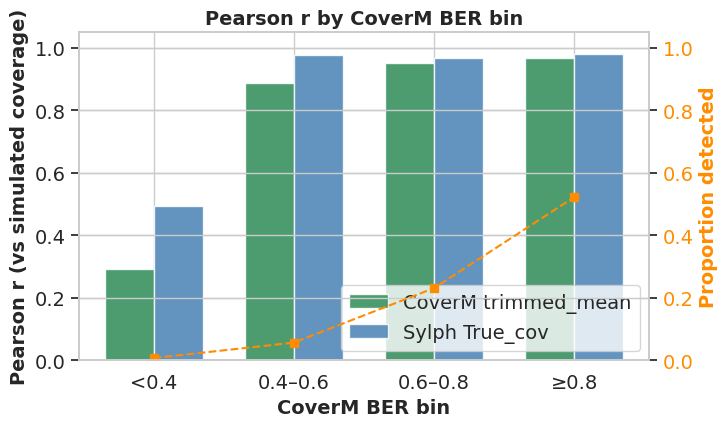

In [331]:
# Analysis 2: summary — Pearson r vs BER bin for both estimators
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(a2_stats_df))
w = 0.35
ax1.bar(x - w / 2, a2_stats_df['pearson_r_coverm'], width=w, label='CoverM trimmed_mean', color='seagreen', alpha=0.85)
ax1.bar(x + w / 2, a2_stats_df['pearson_r_sylph'], width=w, label='Sylph True_cov', color='steelblue', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(a2_stats_df['ber_bin'])
ax1.set_ylabel('Pearson r (vs simulated coverage)')
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('CoverM BER bin')
ax1.legend(loc='lower right')
ax1.set_title('Pearson r by CoverM BER bin')

ax2 = ax1.twinx()
ax2.plot(x, a2_stats_df['prop_detected'], marker='s', linestyle='--', color='darkorange')
ax2.set_ylabel('Proportion detected', color='darkorange')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.tight_layout()
plt.show()

,breadth_ratio_min,n_coverm,n_sylph,recall_coverm,recall_sylph
0,0.00,1389,1390,0.817059,0.817647
1,0.05,1389,1390,0.817059,0.817647
2,0.10,1389,1390,0.817059,0.817647
3,0.15,1389,1390,0.817059,0.817647
4,0.20,1389,1390,0.817059,0.817647
5,0.25,1388,1389,0.816471,0.817059
6,0.30,1386,1387,0.815294,0.815882
7,0.35,1381,1382,0.812353,0.812941
8,0.40,1377,1378,0.810000,0.810588
9,0.45,1368,1369,0.804706,0.805294


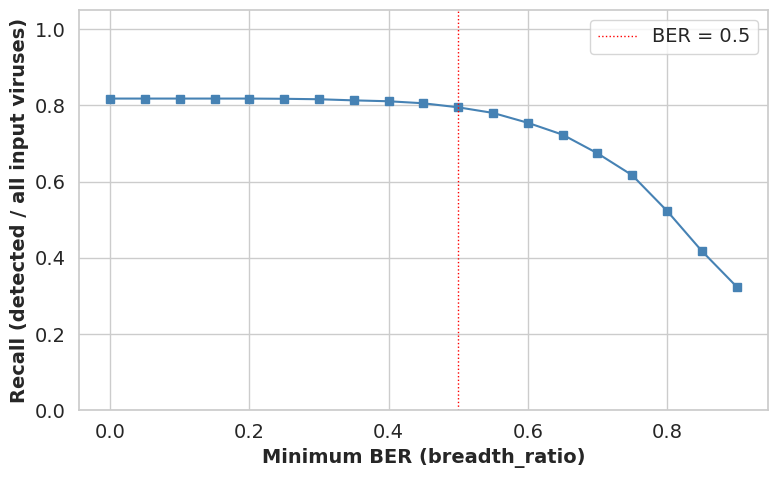

In [332]:
# Analysis 2: recall vs minimum BER threshold
# recall = (# inputs detected with BER >= threshold) / (total input viruses)
n_total_inputs = input_vs_detected.height
recall_rows = []
for br in MIN_BER_SWEEP:
    sub = input_vs_detected.filter(
        pl.col('breadth_ratio').is_not_null()
        & (pl.col('breadth_ratio') >= br)
    )
    n_coverm = sub.filter(pl.col('trimmed_mean') > DETECT_THRESH).height
    n_sylph = sub.filter(pl.col('True_cov') > DETECT_THRESH).height
    recall_rows.append({
        'breadth_ratio_min': br,
        'n_coverm': n_coverm,
        'n_sylph': n_sylph,
        'recall_coverm': n_coverm / n_total_inputs,
        'recall_sylph': n_sylph / n_total_inputs,
    })

a2_recall_df = pd.DataFrame(recall_rows)
display(a2_recall_df)

fig, ax = plt.subplots(figsize=(8, 5))
# ax.plot(a2_recall_df['breadth_ratio_min'], a2_recall_df['recall_coverm'],
#         marker='o', color='seagreen', label='CoverM trimmed_mean')
ax.plot(a2_recall_df['breadth_ratio_min'], a2_recall_df['recall_sylph'],
        marker='s', color='steelblue')
ax.axvline(0.5, color='red', linestyle=':', linewidth=1, label='BER = 0.5')
ax.set_xlabel('Minimum BER (breadth_ratio)')
ax.set_ylabel('Recall (detected / all input viruses)')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


Pearson r (BER vs match_tcov) = 0.613, n = 1389


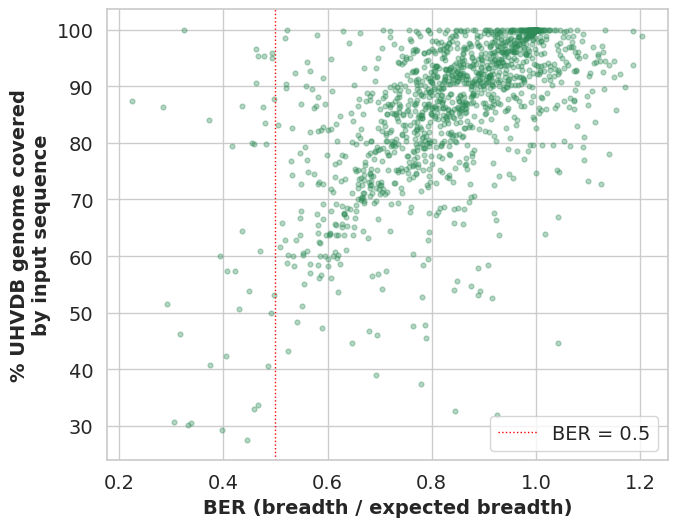

In [333]:
# Analysis 2: correlation between CoverM BER and BLAST tcov (RBH pairs only)
# match_tcov = % of UHVDB genome aligned to the assigned input (0–100)
ber_tcov = input_vs_detected.filter(
    pl.col('breadth_ratio').is_not_null()
    & pl.col('match_tcov').is_not_null()
    & (pl.col('trimmed_mean') > DETECT_THRESH)
)

r_bt, n_bt = safe_pearson(ber_tcov['breadth_ratio'].to_list(), ber_tcov['match_tcov'].to_list())
print(f'Pearson r (BER vs match_tcov) = {r_bt:.3f}, n = {n_bt}')

ber_tcov_pd = ber_tcov.to_pandas()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(
    ber_tcov_pd['breadth_ratio'],
    ber_tcov_pd['match_tcov'],
    s=12, alpha=0.35, color='seagreen',
)
ax.axvline(0.5, color='red', linestyle=':', linewidth=1, label='BER = 0.5')
ax.set_xlabel('BER (breadth / expected breadth)')
ax.set_ylabel('% UHVDB genome covered\nby input sequence')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Analysis 2b — Proportion with RBH by CoverM BER

Same structure as the tcov RBH-rate plot: among inputs with a best-tANI link to a sylph-detected contig that has CoverM metrics, bin by that contig's BER and report the fraction that are reciprocal best hits.


,ber_bin,n_total,n_rbh,prop_rbh
0,<0.4,13,10,0.769231
1,0.4–0.5,29,25,0.862069
2,0.5–0.6,74,69,0.932432
3,0.6–0.7,149,136,0.912752
4,0.7–0.8,279,258,0.924731
5,0.8–0.9,377,338,0.896552
6,≥0.9,594,553,0.930976


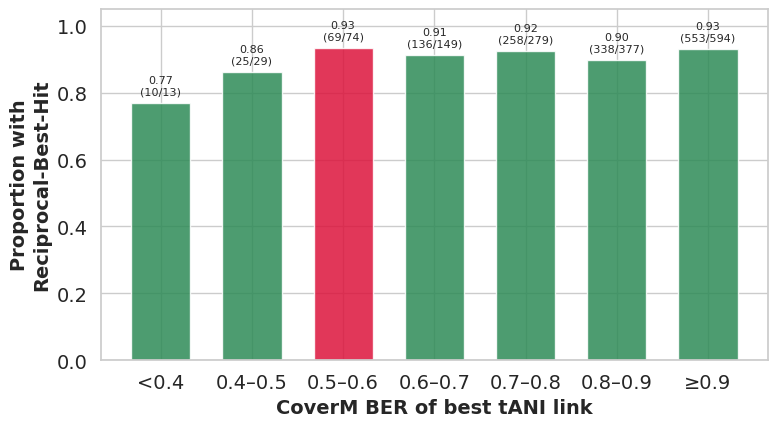

In [334]:
# Analysis 2b: proportion with RBH vs CoverM BER of best tANI link
# Parallel to Analysis 1c tcov plot; uses best-link CoverM BER (not RBH-only)
BER_RBH_EDGES = [0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 100.0]
BER_RBH_LABELS = ['<0.4', '0.4–0.5', '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '≥0.9']

def assign_ber_rbh_bin(ber: float) -> str:
    for hi, lab in zip(BER_RBH_EDGES[1:], BER_RBH_LABELS):
        if ber < hi:
            return lab
    return BER_RBH_LABELS[-1]

ber_df = (
    input_vs_detected
    .filter(
        pl.col('best_link_breadth_ratio').is_not_null()
        & (pl.col('best_link_trimmed_mean') > DETECT_THRESH)
    )
    .with_columns(
        pl.col('best_link_breadth_ratio')
        .map_elements(assign_ber_rbh_bin, return_dtype=pl.Utf8)
        .alias('best_link_ber_bin')
    )
)

rbh_by_ber = []
for label in BER_RBH_LABELS:
    sub = ber_df.filter(pl.col('best_link_ber_bin') == label)
    n_total = sub.height
    n_rbh = sub.filter(pl.col('has_rbh')).height
    rbh_by_ber.append({
        'ber_bin': label,
        'n_total': n_total,
        'n_rbh': n_rbh,
        'prop_rbh': n_rbh / n_total if n_total else np.nan,
    })

rbh_ber_df = pd.DataFrame(rbh_by_ber)
display(rbh_ber_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(rbh_ber_df))
bar_colors = ['crimson' if lab == '0.5–0.6' else 'seagreen' for lab in rbh_ber_df['ber_bin']]
ax.bar(x, rbh_ber_df['prop_rbh'], color=bar_colors, alpha=0.85, width=0.65)
ax.set_xticks(x)
ax.set_xticklabels(rbh_ber_df['ber_bin'])
ax.set_xlabel('CoverM BER of best tANI link')
ax.set_ylabel('Proportion with\nReciprocal-Best-Hit')
ax.set_ylim(0, 1.05)
for i, (p, n, tot) in enumerate(zip(rbh_ber_df['prop_rbh'], rbh_ber_df['n_rbh'], rbh_ber_df['n_total'])):
    y = p if np.isfinite(p) else 0.0
    ax.text(i, y + 0.02, f'{p:.2f}\n({n}/{tot})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Analysis 2c — Proportion of low-tcov (<60%) links by CoverM BER

Among inputs with a best-tANI link to a sylph-detected contig that has CoverM metrics, bin by that contig's BER and report the fraction with BLAST `tcov < 60%` (partial / likely false-positive style matches).


,ber_bin,n_total,n_low_tcov,prop_low_tcov
0,<0.4,13,8,0.615385
1,0.4–0.5,29,8,0.275862
2,0.5–0.6,74,6,0.081081
3,0.6–0.7,149,10,0.067114
4,0.7–0.8,279,5,0.017921
5,0.8–0.9,377,11,0.029178
6,≥0.9,594,9,0.015152


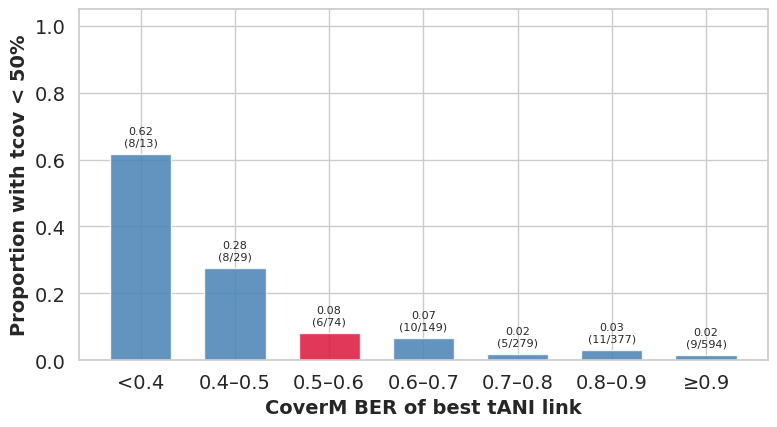

In [336]:
# Analysis 2c: proportion with tcov < 60% vs CoverM BER of best tANI link
# Same cohort / BER bins as Analysis 2b
BER_FP_EDGES = [0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 100.0]
BER_FP_LABELS = ['<0.4', '0.4–0.5', '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '≥0.9']
TCOV_FP_THRESH = 50.0  # percent

def assign_ber_fp_bin(ber: float) -> str:
    for hi, lab in zip(BER_FP_EDGES[1:], BER_FP_LABELS):
        if ber < hi:
            return lab
    return BER_FP_LABELS[-1]

fp_df = (
    input_vs_detected
    .filter(
        pl.col('best_link_breadth_ratio').is_not_null()
        & pl.col('best_link_tcov').is_not_null()
        & (pl.col('best_link_trimmed_mean') > DETECT_THRESH)
    )
    .with_columns([
        pl.col('best_link_breadth_ratio')
        .map_elements(assign_ber_fp_bin, return_dtype=pl.Utf8)
        .alias('best_link_ber_bin'),
        (pl.col('best_link_tcov') < TCOV_FP_THRESH).alias('low_tcov'),
    ])
)

fp_by_ber = []
for label in BER_FP_LABELS:
    sub = fp_df.filter(pl.col('best_link_ber_bin') == label)
    n_total = sub.height
    n_fp = sub.filter(pl.col('low_tcov')).height
    fp_by_ber.append({
        'ber_bin': label,
        'n_total': n_total,
        'n_low_tcov': n_fp,
        'prop_low_tcov': n_fp / n_total if n_total else np.nan,
    })

fp_ber_df = pd.DataFrame(fp_by_ber)
display(fp_ber_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(fp_ber_df))
bar_colors = ['crimson' if lab == '0.5–0.6' else 'steelblue' for lab in fp_ber_df['ber_bin']]
ax.bar(x, fp_ber_df['prop_low_tcov'], color=bar_colors, alpha=0.85, width=0.65)
ax.set_xticks(x)
ax.set_xticklabels(fp_ber_df['ber_bin'])
ax.set_xlabel('CoverM BER of best tANI link')
ax.set_ylabel(f'Proportion with tcov < {TCOV_FP_THRESH:.0f}%')
ax.set_ylim(0, 1.05)
for i, (p, n, tot) in enumerate(zip(fp_ber_df['prop_low_tcov'], fp_ber_df['n_low_tcov'], fp_ber_df['n_total'])):
    y = p if np.isfinite(p) else 0.0
    ax.text(i, y + 0.02, f'{p:.2f}\n({n}/{tot})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()